# Monetary policy introduction

This notebook studies monetary policy in the canonical HANK model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

import sim_steady_state_fast as sim
import sim_fake_news
from calibration import make_calibration, load_betas

In [2]:
# for plotting: uncomment second line to get plots with exact style
plt.rcParams.update({'font.size': 10, 'font.family': 'serif', 'figure.figsize': (6, 3)})
plt.rcParams.update({'text.usetex': True, 'font.serif': 'Palatino'})
colors = plt.cm.Blues(np.linspace(0.5, 1, 4)[::-1])

## RANK prelude

Forward guidance shock: 1pp decrease in the real rate at $T^{fg}$ quarters.

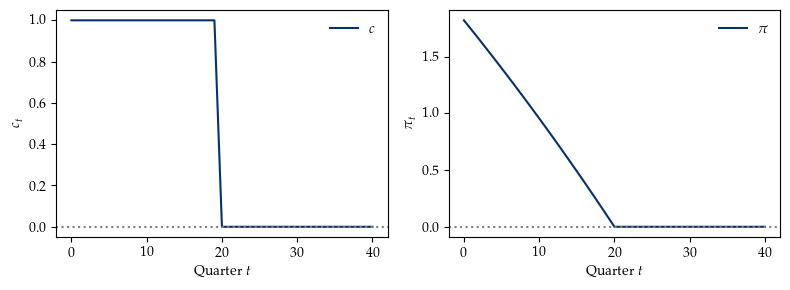

In [3]:
T = 50
Tfg = 20
beta = 0.99
kappa = 0.1

dC = np.zeros(T)
dC[:Tfg] = 1
pi = np.empty(T)
for t in range(T):
    pi[t] = kappa * (beta**np.arange(T - t) @ dC[t:])

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].plot(dC[:41], label=r'$c$', color=colors[0])
axes[1].plot(pi[:41], label=r'$\pi$', color=colors[0])

for ax, ylabel in zip(axes, [r'$c_t$', r'$\pi_t$']):
    ax.set_xlabel(r'Quarter $t$')
    ax.set_ylabel(ylabel)
    ax.axhline(y=0, linestyle='dotted', color='gray')
    ax.legend(frameon=False)

fig.tight_layout()
fig.savefig("figures/lecture4_ra_C_pi.pdf", transparent=True, bbox_inches='tight')

Same, but assuming ad-hoc discounting of $\delta$ in the Euler equation.

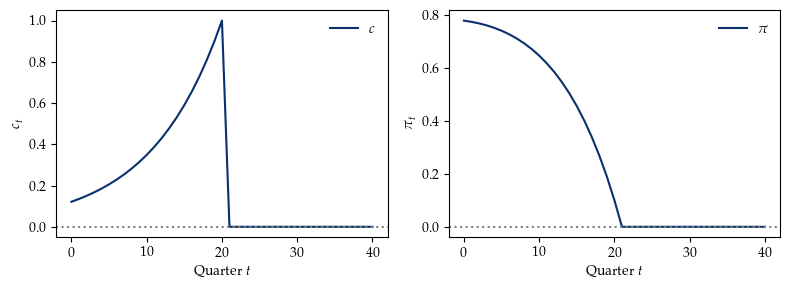

In [4]:
delta = 0.9

dC = np.zeros(T)
dC[Tfg] = 1
for t in reversed(range(Tfg)):
    dC[t] = delta * dC[t + 1]

pi = np.empty(T)
for t in range(T):
    pi[t] = kappa * (beta**np.arange(T - t) @ dC[t:])

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].plot(dC[:41], label=r'$c$', color=colors[0])
axes[1].plot(pi[:41], label=r'$\pi$', color=colors[0])

for ax, ylabel in zip(axes, [r'$c_t$', r'$\pi_t$']):
    ax.set_xlabel(r'Quarter $t$')
    ax.set_ylabel(ylabel)
    ax.axhline(y=0, linestyle='dotted', color='gray')
    ax.legend(frameon=False)

fig.tight_layout()
fig.savefig("figures/lecture4_ra_C_pi_discount.pdf", transparent=True, bbox_inches='tight')

## Low-asset HANK calibration

In [5]:
calib, e = make_calibration(lowA=True)
ss = sim.steady_state(**calib)

pi = sim.stationary_markov(ss['Pi'])
Z = np.sum(pi * ss['y'])
assert np.isclose(ss['A'] / 4, 1)

print(f"Steady state: Z={Z:.4f}, r={ss['r']:.4f}, C={ss['C']:.4f}, A={ss['A']:.4f}")

T = 400

Steady state: Z=0.7000, r=0.0050, C=0.7200, A=4.0000


## Intertemporal MPCs and interest-rate Jacobians

In [6]:
J = sim_fake_news.jacobian(ss, {'Z': {'y': e}}, T=T)
M, A = J['C']['Z'], J['A']['Z']
assert np.isclose(M[0, 0], 0.2)

Jr = sim_fake_news.jacobian(ss, {'r': {'r': 1}}, T=T + 1)

# Mr, Ar are dC/dlog(1+r) and dA/dlog(1+r), respectively.
# The first column is the response to ex-post r0, which we ignore.
Mr = Jr['C']['r'][:-1, 1:] * (1 + ss['r'])
Ar = Jr['A']['r'][:-1, 1:] * (1 + ss['r'])

Check iMPCs are what we expect.

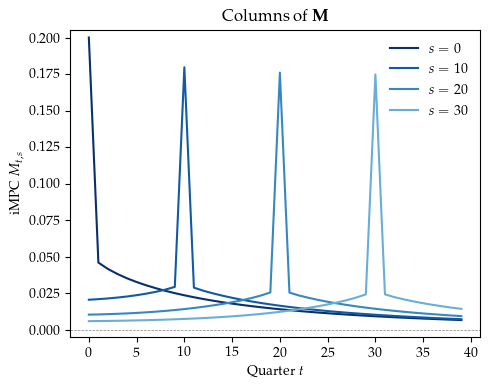

In [7]:
plt.figure(figsize=(5, 4))
for i, s in enumerate([0, 10, 20, 30]):
    plt.plot(M[:40, s], label=f'$s={s}$', color=colors[i])
plt.xlabel('Quarter $t$')
plt.ylabel('iMPC $M_{t,s}$')
plt.title(r'Columns of $\mathbf{M}$')
plt.legend(frameon=False)
plt.tight_layout()
plt.ylim(-0.005, 0.205)
plt.axhline(0, linestyle='--', color='grey', linewidth=0.5);

Now plot $-M^{r^{ante}}$.

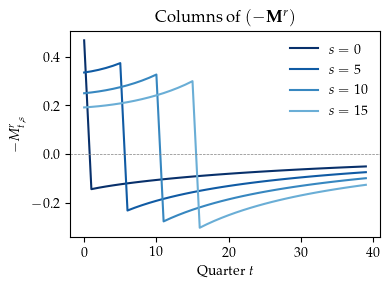

In [8]:
plt.figure(figsize=(4, 3))
for i, s in enumerate([0, 5, 10, 15]):
    plt.plot(-Mr[:40, s], label=f'$s={s}$', color=colors[i])
plt.xlabel('Quarter $t$')
plt.ylabel(r'$-M^r_{t,s}$')
plt.title(r'Columns of $(-\mathbf{M}^r)$')
plt.legend(frameon=False)
plt.tight_layout()
plt.axhline(0, linestyle='--', color='grey', linewidth=0.5)
plt.savefig('figures/lecture4_minus_Mr.pdf', transparent=True, bbox_inches='tight')

## Partial equilibrium effect of an interest-rate shock

In [9]:
# dr is the change in r, divided by steady-state 1+r
dr = -0.25 * 0.9**np.arange(T) / (1 + ss['r'])
dC_r = Mr @ dr

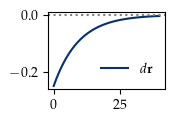

In [10]:
plt.figure(figsize=(1.5, 1))
plt.plot(dr[:41], label=r'$d\mathbf{r}$', color=colors[0])
plt.axhline(y=0, linestyle='dotted', color='gray')
plt.legend(frameon=False)
plt.savefig("figures/lecture4_dr.pdf", transparent=True, bbox_inches='tight')

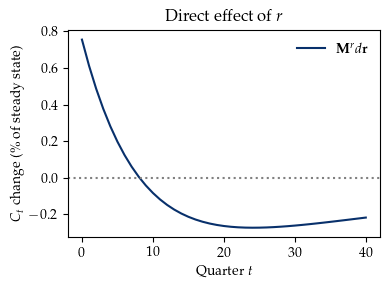

In [11]:
plt.figure(figsize=(4, 3))
plt.title(r'Direct effect of $r$')
plt.plot(dC_r[:41], label=r'$\mathbf{M}^rd\mathbf{r}$', color=colors[0])
plt.xlabel(r'Quarter $t$')
plt.ylabel(r'$C_t$ change (\% of steady state)')
plt.axhline(y=0, linestyle='dotted', color='gray')
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig("figures/lecture4_Mrdr.pdf", transparent=True, bbox_inches='tight')

## General equilibrium

Linearize asset market clearing:
$$ d\mathbf{Y}=B_{ss}d\mathbf{r}-\mathbf{A}^{-1}\left(B_{ss}d\mathbf{r}+\mathbf{A}_{r}d\mathbf{r}\right) $$

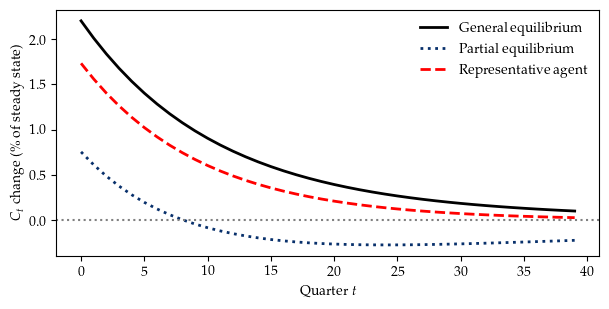

In [12]:
dY = ss['A'] * dr - np.linalg.solve(A, ss['A'] * dr + Ar @ dr)

# Calculate representative-agent response.
dCra = np.empty(T)
dCra[-1] = 0
for t in reversed(range(T - 1)):
    dCra[t] = dCra[t + 1] - Z * calib['eis'] * dr[t] / (1 + calib['r'])
    
plt.plot(dY[:40], label='General equilibrium', color='black', linewidth=2)
plt.plot(dC_r[:40], label='Partial equilibrium', color=colors[0], linestyle='dotted', linewidth=2)
plt.plot(dCra[:40], label='Representative agent', color='red', linestyle='dashed', linewidth=2)
plt.axhline(y=0, linestyle='dotted', color='gray')
plt.legend(frameon=False)
plt.tight_layout()
plt.ylabel(r'$C_t$ change (\% of steady state)')
plt.xlabel(r'Quarter $t$')
plt.savefig('figures/lecture4_ge.pdf', transparent=True, bbox_inches='tight')

Decompose the general-equilibrium response into the direct interest-rate effect and the indirect income and tax channels.

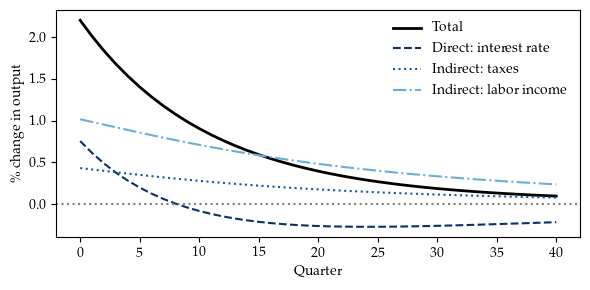

In [13]:
dC_r = Mr @ dr
dC_labor = M @ dY
dC_tax = -ss['A'] * M @ dr

plt.plot(dY[:41], label='Total', color='black', linewidth=2)
plt.plot(dC_r[:41], label='Direct: interest rate', linestyle='dashed', color=colors[0])
plt.plot(dC_tax[:41], label='Indirect: taxes', linestyle='dotted', color=colors[1])
plt.plot(dC_labor[:41], label='Indirect: labor income', linestyle='dashdot', color=colors[3])
plt.axhline(y=0, linestyle='dotted', color='gray')
plt.legend(frameon=False)
plt.xlabel('Quarter')
plt.ylabel(r'\% change in output')
plt.tight_layout()
plt.savefig('figures/lecture4_decomposition.pdf', transparent=True, bbox_inches='tight')

In [14]:
dY[0:5]

array([2.20168862, 2.01042256, 1.83640983, 1.67813562, 1.53416291])

## Zero-liquidity limit

In [15]:
dbeta = load_betas()['A_100']['dbeta']
n_e = round(len(calib['y']) / 4)

In [16]:
A_target = 1e-6

def evaluate_calibration_simple(x):
    beta = np.kron([x - 3 * dbeta, x - 2 * dbeta, x - dbeta, x], np.ones(n_e))[:, np.newaxis]
    calib_zl = {**calib, 'beta': beta}
    ss = sim.steady_state(**calib_zl)
    return ss['A'] - A_target

res = optimize.root_scalar(evaluate_calibration_simple, bracket=[0.8, 0.99], xtol=1e-9)
assert res.converged

In [17]:
betah_zl = res.root
beta_zl = np.kron(
    [betah_zl - 3 * dbeta, betah_zl - 2 * dbeta, betah_zl - dbeta, betah_zl],
    np.ones(n_e)
)[:, np.newaxis]
calib_zl = {**calib, 'beta': beta_zl}
ss_zl = sim.steady_state(**calib_zl)

In [18]:
J_zl = sim_fake_news.jacobian(ss_zl, {'Z': {'y': e}}, T=T)
M_zl, A_zl = J_zl['C']['Z'], J_zl['A']['Z']
Jr_zl = sim_fake_news.jacobian(ss_zl, {'r': {'r': 1}}, T=T + 1)
Mr_zl = Jr_zl['C']['r'][:-1, 1:] * (1 + ss_zl['r'])
Ar_zl = Jr_zl['A']['r'][:-1, 1:] * (1 + ss_zl['r'])

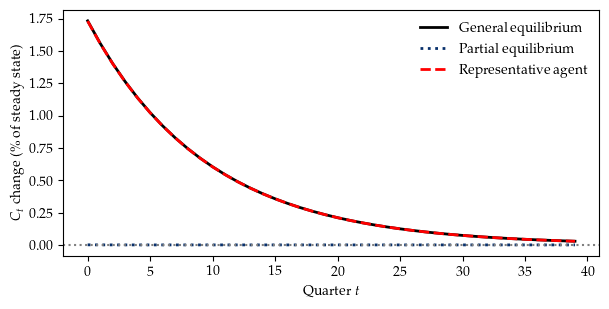

In [19]:
dY_zl = ss_zl['A'] * dr - np.linalg.solve(A_zl, ss_zl['A'] * dr + Ar_zl @ dr)

plt.plot(dY_zl[:40], label='General equilibrium', color='black', linewidth=2)
plt.plot((Mr_zl @ dr)[:40], label='Partial equilibrium', color=colors[0], linestyle='dotted', linewidth=2)
plt.plot(dCra[:40], label='Representative agent', color='red', linestyle='dashed', linewidth=2)


plt.axhline(y=0, linestyle='dotted', color='gray')
plt.legend(frameon=False)
plt.tight_layout()
plt.ylabel(r'$C_t$ change (\% of steady state)')
plt.xlabel(r'Quarter $t$')
plt.savefig('figures/lecture4_zl.pdf', transparent=True, bbox_inches='tight')

## Forward guidance shock

In [20]:
dr = np.zeros(T)
dr[Tfg] = -0.25 / (1 + ss['r'])

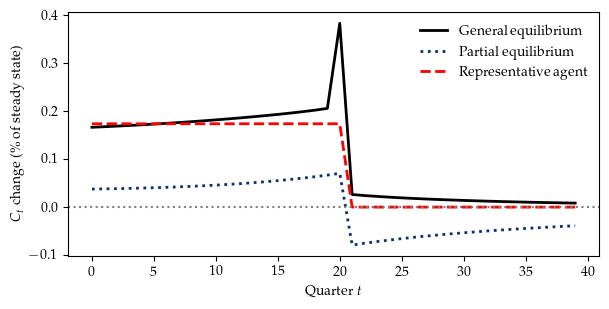

In [21]:
dC_r = Mr @ dr
dY = ss['A'] * dr - np.linalg.solve(A, ss['A'] * dr + Ar @ dr)

# Calculate representative-agent response.
dCra = np.empty(T)
dCra[-1] = 0
for t in reversed(range(T - 1)):
    dCra[t] = dCra[t + 1] - Z * calib['eis'] * dr[t] / (1 + calib['r'])
    
plt.plot(dY[:40], label='General equilibrium', color='black', linewidth=2)
plt.plot(dC_r[:40], label='Partial equilibrium', color=colors[0], linestyle='dotted', linewidth=2)
plt.plot(dCra[:40], label='Representative agent', color='red', linestyle='dashed', linewidth=2)
plt.axhline(y=0, linestyle='dotted', color='gray')
plt.legend(frameon=False)
plt.tight_layout()
plt.ylabel(r'$C_t$ change (\% of steady state)')
plt.xlabel(r'Quarter $t$')
plt.savefig('figures/lecture4_fg.pdf', transparent=True, bbox_inches='tight')

In [22]:
dY[0:5]

array([0.16598203, 0.16714389, 0.16838086, 0.16969423, 0.17108764])